# T18 — Debugging a plate model: velocity magnitude at MOR topologies (PlateTectonicTools)

**Cluster C: Plate-model debugging.** (2 / 4).

## What this notebook does

T17 focused on **sign anomalies** at plate boundaries — ridges that converge, trenches that diverge. T18 focuses on **magnitude anomalies** at mid-ocean ridges: which ridge segments have spreading rates that look implausibly high (> \~15 cm/yr, close to the fastest observed on modern Earth) or implausibly low (< \~0.5 cm/yr, close to the resolution of most rotation models).

The heavy lifting is done by [PlateTectonicTools](https://github.com/EarthByte/PlateTectonicTools)' `tessellate_mid_ocean_ridges` — this returns a table of point locations along every resolved MOR line, each with its full spreading rate in cm/yr. Note that unlike T17's `diagnose_topology_convergence`, PTT does not detect negative divergence — it returns absolute spreading rate magnitudes only.

**Sections:**

1. **§1** Load plate model + PlateTectonicTools helper.
2. **§2** For each of the five snapshot ages (100, 125, 150, 175, 200 Ma), tessellate MOR sub-segments and compute the absolute spreading rate at each midpoint.
3. **§3** One pyGMT map per snapshot — MOR midpoints coloured by spreading rate using a batlow palette clipped to 0-15 cm/yr, with `+ef` overflow arrow flagging anything above.
4. **§4** Compact MP4 video at 1-Myr cadence over 100-200 Ma.
5. **§5** Extend this — swap plate models, change the CPT range, add trench velocities for comparison.

**Reading the results.** Ridges in the modern ocean spread between \~1 cm/yr (Arctic, ultra-slow) and \~15 cm/yr (East Pacific Rise, super-fast). Rates outside that envelope at any Cenozoic-or-younger age suggest a rotation problem or a topology-drawing issue (e.g. a wrong plate-ID at one end of the ridge segment produces spurious ultra-fast values). Deeper in time (Mesozoic and older), the envelope legitimately widens because reconstructions become less constrained, so treat 100 Ma results as your baseline and the older snapshots with more scepticism.

**Audience**: intermediate → researcher.
**Difficulty**: ★★☆.
**Runtime**: \~45 s for the 5 static snapshots; \~4-6 min for the 1-Myr video (101 frames).


## Data availability

**Plate model** — Zahirovic 2022 (`Zahirovic2022`), fetched via the Plate Model Manager. Any PMM model can be swapped in.

**Helper module** — `Notebooks/plate_model_debug/` (bundled with the suite).

## Sources

- Sculley, B. & Cannon, J. (2025) *plate-model-debug*. EarthByte, University of Sydney. Companion code.
- Zahirovic, S., Eleish, A., Doss, S., Pall, J., Cannon, J., Pistone, M., Tetley, M.G., Young, A. & Fox, P. (2022). Subduction and carbonate platform interactions. *Geoscience Data Journal* 9(2), 371-383. https://doi.org/10.1002/gdj3.146


## Environment + imports


In [1]:
from pathlib import Path
import os, sys
if Path("../data").exists() and not Path("data").exists():
    os.chdir("..")

import numpy as np
import gplately
import pygmt
import pygplates
from plate_model_manager import PlateModelManager

print("Environment")
print(f"  python      {sys.version.split()[0]}")
for _m in (np, gplately, pygmt, pygplates):
    print(f"  {_m.__name__:11s} {getattr(_m, '__version__', 'n/a')}")


Environment
  python      3.11.15
  numpy       2.4.4
  gplately    2.0.0
  pygmt       v0.17.0
  pygplates   1.0.0


In [2]:
# === USER CONFIGURATION =====================================================
MODEL_NAME             = "Zahirovic2022"
ANCHOR_PLATE_ID        = 0

SNAPSHOT_AGES_MA       = [100, 125, 150, 175, 200]

# Video window + settings (compact defaults matching T17).
VIDEO_START_MA         = 200
VIDEO_END_MA           = 100
VIDEO_CADENCE_MA       = 1
VIDEO_FPS              = 10
VIDEO_WIDTH_PX         = 800
VIDEO_CRF              = 28

# Physical cap on plausible spreading rate (cm/yr). Points reported above
# this are almost always PTT-tessellation artifacts at ridge-transform
# intersections where the local great-circle geometry degenerates (short
# arc lengths, ambiguous ridge-vs-transform classification at the junction).
# Earth's fastest observed MOR rates are ~16 cm/yr at the East Pacific Rise;
# 20 cm/yr is a generous cap. Set to np.inf to disable filtering.
MAX_MOR_RATE_CMS_YR    = 20.0

# CPT for spreading rate (cm/yr). +ef arrow flags anything above CPT_MAX.
CPT_MIN, CPT_MAX       = 0.0, 15.0
CPT_STEP               = 0.5

# Map region + projection.
REGION_GLOBAL          = [-180, 180, -75, 80]
PROJECTION             = "N15c"

# Output dirs (gitignored).
FRAMES_DIR             = Path("Notebooks/T60_debug_mor_velocity_frames")
VIDEO_DIR              = Path("Notebooks/videos")
VIDEO_PATH             = VIDEO_DIR / "T60_debug_mor_velocity.mp4"
# Plate-motion vector overlay.
ARROW_SPACING_DEG      = 15.0     # grid spacing for arrow sampling (global 15° = readable, regional 3-5°)
ARROW_VEL_SCALE        = 0.08     # cm map length per cm/yr (map-projection-dependent; tune to taste)
ARROW_MIN_SPEED_CM_YR  = 0.5      # arrows below this speed are suppressed (removes near-stationary noise)

# ============================================================================
print(f"  plate model:   {MODEL_NAME}")
print(f"  snapshots:     {SNAPSHOT_AGES_MA} Ma")
print(f"  video window:  {VIDEO_END_MA}-{VIDEO_START_MA} Ma at {VIDEO_CADENCE_MA}-Myr cadence")


  plate model:   Zahirovic2022
  snapshots:     [100, 125, 150, 175, 200] Ma
  video window:  100-200 Ma at 1-Myr cadence


## 1. Load plate model


In [3]:
pmm = PlateModelManager()
model_pmm = pmm.get_model(MODEL_NAME, data_dir="./gplately_data")

_pmm_rot = model_pmm.get_rotation_model()
if not hasattr(_pmm_rot, "get_rotation"):
    rotation_model = pygplates.RotationModel(_pmm_rot)
else:
    rotation_model = _pmm_rot

topology_features = [pygplates.FeatureCollection(f) for f in model_pmm.get_topologies()]
topological_model = pygplates.TopologicalModel(topology_features, rotation_model)

recon = gplately.PlateReconstruction(
    rotation_model=rotation_model,
    topology_features=model_pmm.get_topologies(),
    static_polygons=model_pmm.get_static_polygons(),
    anchor_plate_id=ANCHOR_PLATE_ID,
)
print(f"  plate model loaded: {MODEL_NAME}")


  plate model loaded: Zahirovic2022


## 2. Tessellate MOR sub-segments and compute spreading rates

`gplately.PlateReconstruction.tessellate_mid_ocean_ridges(time)` returns a NumPy array of shape (N, K) where each row is one point along a resolved MOR line at reconstruction age `time`. The columns of interest are lon (0), lat (1), spreading rate in cm/yr (2). This is a thin wrapper around PTT's `separate_ridge_transform_segments.tessellate_mid_ocean_ridges`.


In [4]:
def get_mor_points(time):
    """Return (lon, lat, rate_cm_yr) arrays for all resolved MORs at `time`."""
    data = recon.tessellate_mid_ocean_ridges(float(time), ignore_warnings=True)
    if data is None or len(data) == 0:
        return np.array([]), np.array([]), np.array([])
    lon = np.asarray(data[:, 0], dtype=float)
    lat = np.asarray(data[:, 1], dtype=float)
    rate = np.asarray(data[:, 2], dtype=float)  # cm/yr
    # Filter out PTT-tessellation artifacts at ridge-transform intersections
    _artifact_mask = rate > MAX_MOR_RATE_CMS_YR
    if _artifact_mask.any():
        n_bad = int(_artifact_mask.sum())
        rate_bad_max = float(rate[_artifact_mask].max())
        print(f"    dropped {n_bad} PTT-tessellation-artifact point(s) with rate > "
              f"{MAX_MOR_RATE_CMS_YR} cm/yr (max seen: {rate_bad_max:.1f} cm/yr)")
        keep = ~_artifact_mask
        lon, lat, rate = lon[keep], lat[keep], rate[keep]
    return lon, lat, rate

# Quick sanity at 150 Ma
_lon, _lat, _rate = get_mor_points(150.0)
print(f"  150 Ma:  {len(_lon)} MOR midpoints, "
      f"rate range {_rate.min():.2f}-{_rate.max():.2f} cm/yr  "
      f"(median {np.median(_rate):.2f} cm/yr)")


  150 Ma:  11497 MOR midpoints, rate range 0.04-17.40 cm/yr  (median 4.87 cm/yr)


## 3. Static snapshots at 100, 125, 150, 175, 200 Ma

Batlow palette 0-15 cm/yr. Yellow-orange = fast spreading (East-Pacific-Rise-like), dark blue = slow (Arctic-like). Points above 15 cm/yr saturate to the top-end colour; the `+ef` arrow on the right end of the horizontal colour bar flags this. A quick eyeball scan of any snapshot should show a coherent global pattern — implausible bright yellow along a segment that shouldn't be fast is a candidate anomaly.


  rendering 100 Ma ...


    (skip velocity arrows: NameError: name 'calculate_plate_motion_arrows' is not defined)


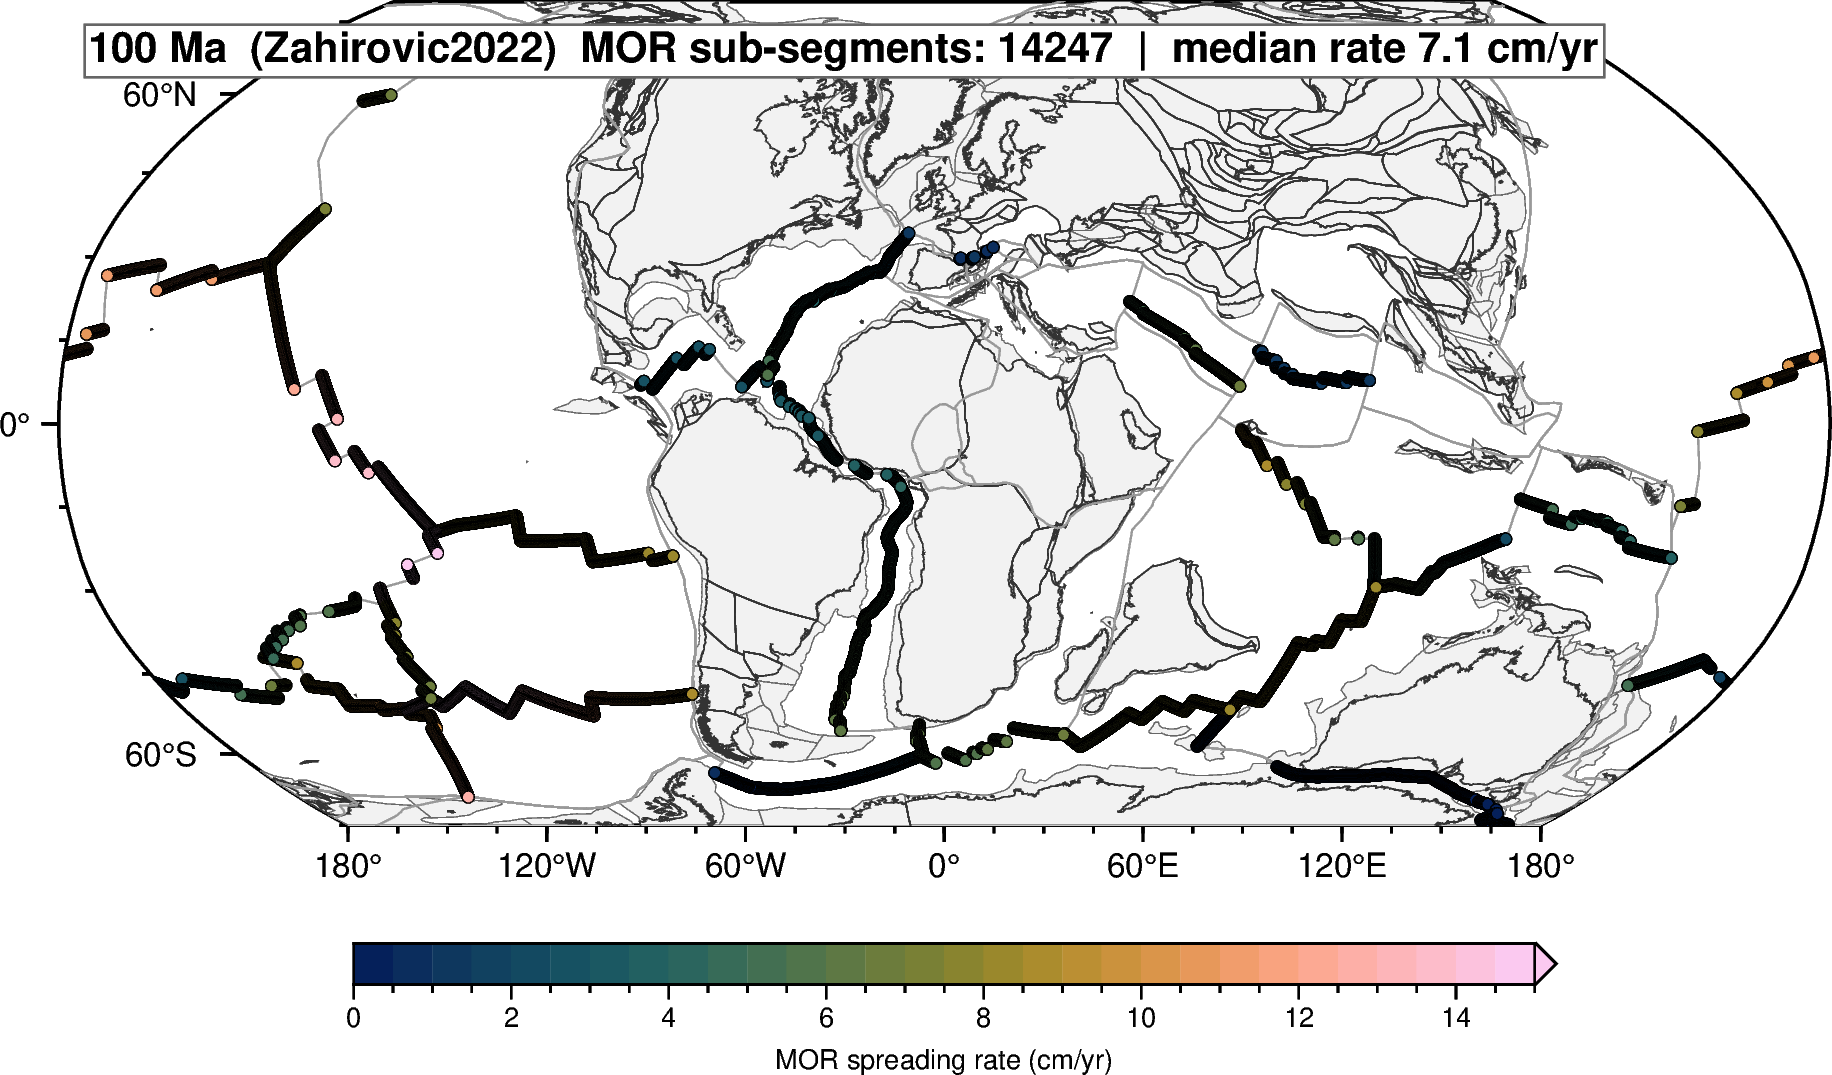

  rendering 125 Ma ...


    dropped 166 PTT-tessellation-artifact point(s) with rate > 20.0 cm/yr (max seen: 24.3 cm/yr)


    (skip velocity arrows: NameError: name 'calculate_plate_motion_arrows' is not defined)


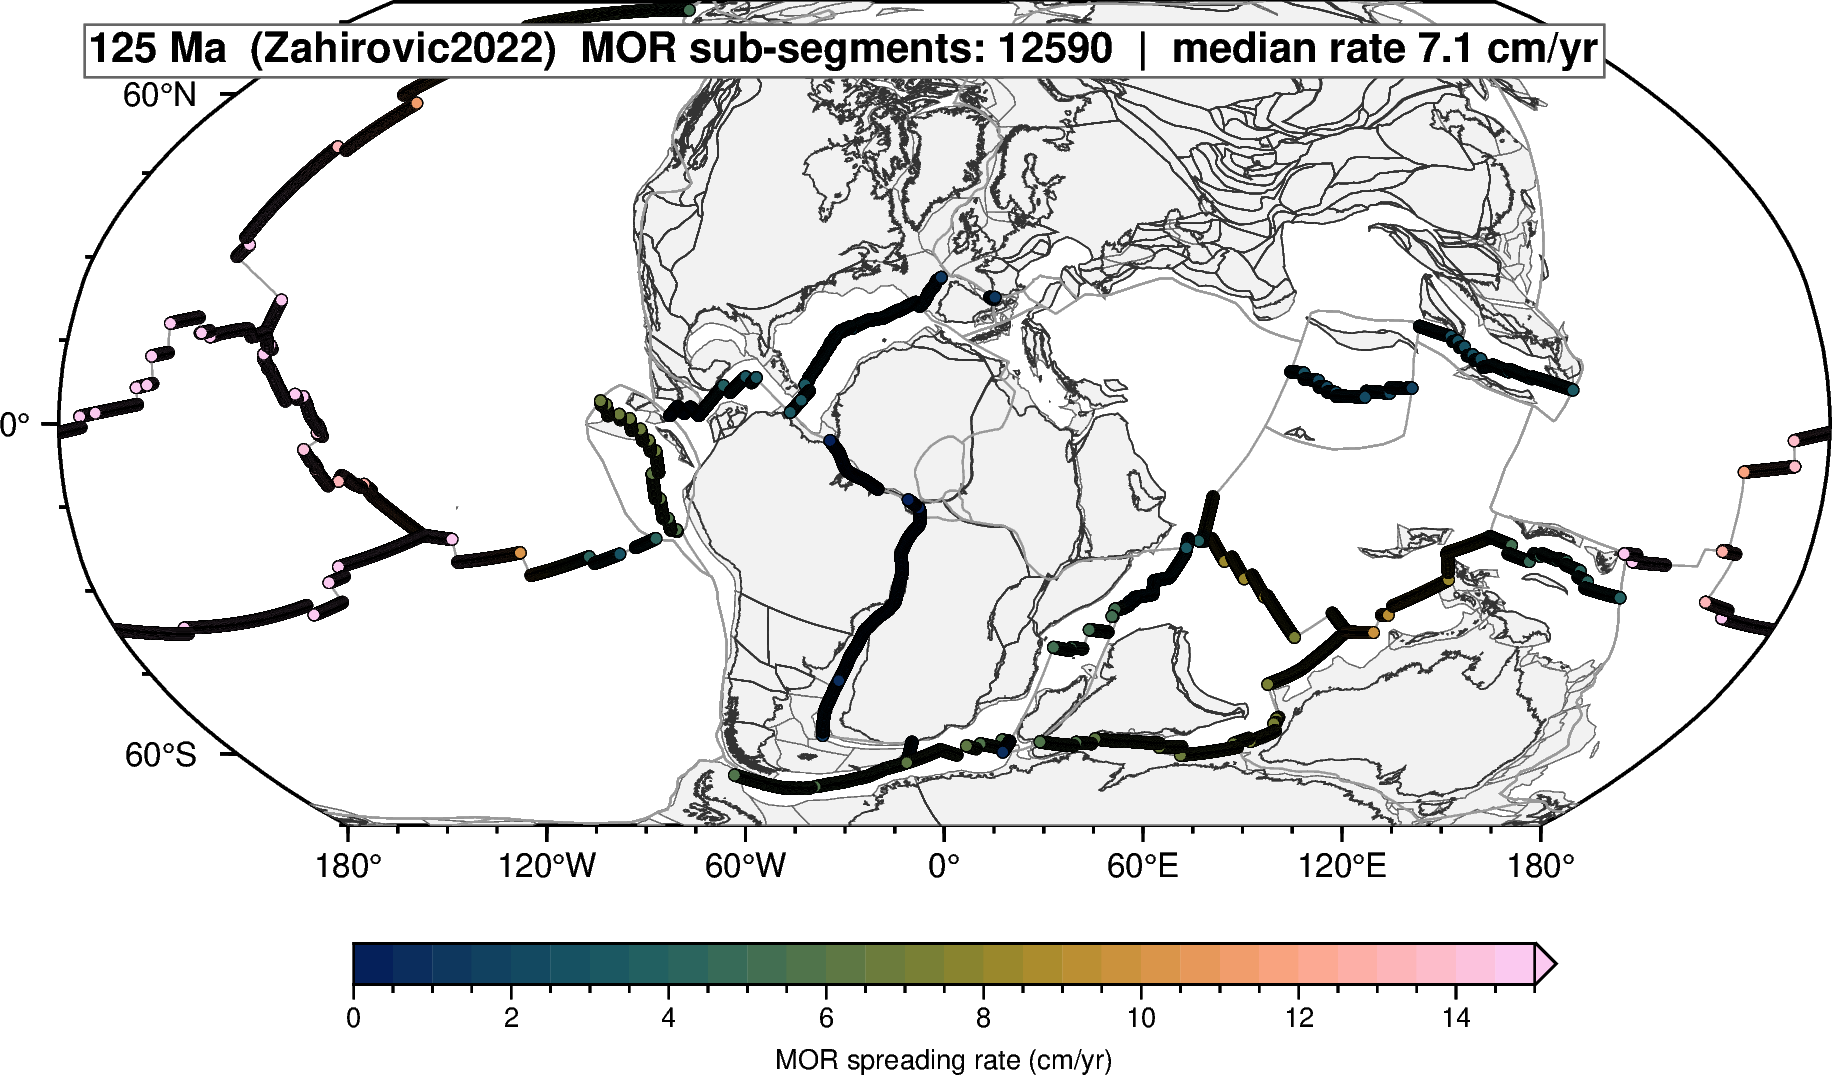

  rendering 150 Ma ...


    (skip velocity arrows: NameError: name 'calculate_plate_motion_arrows' is not defined)


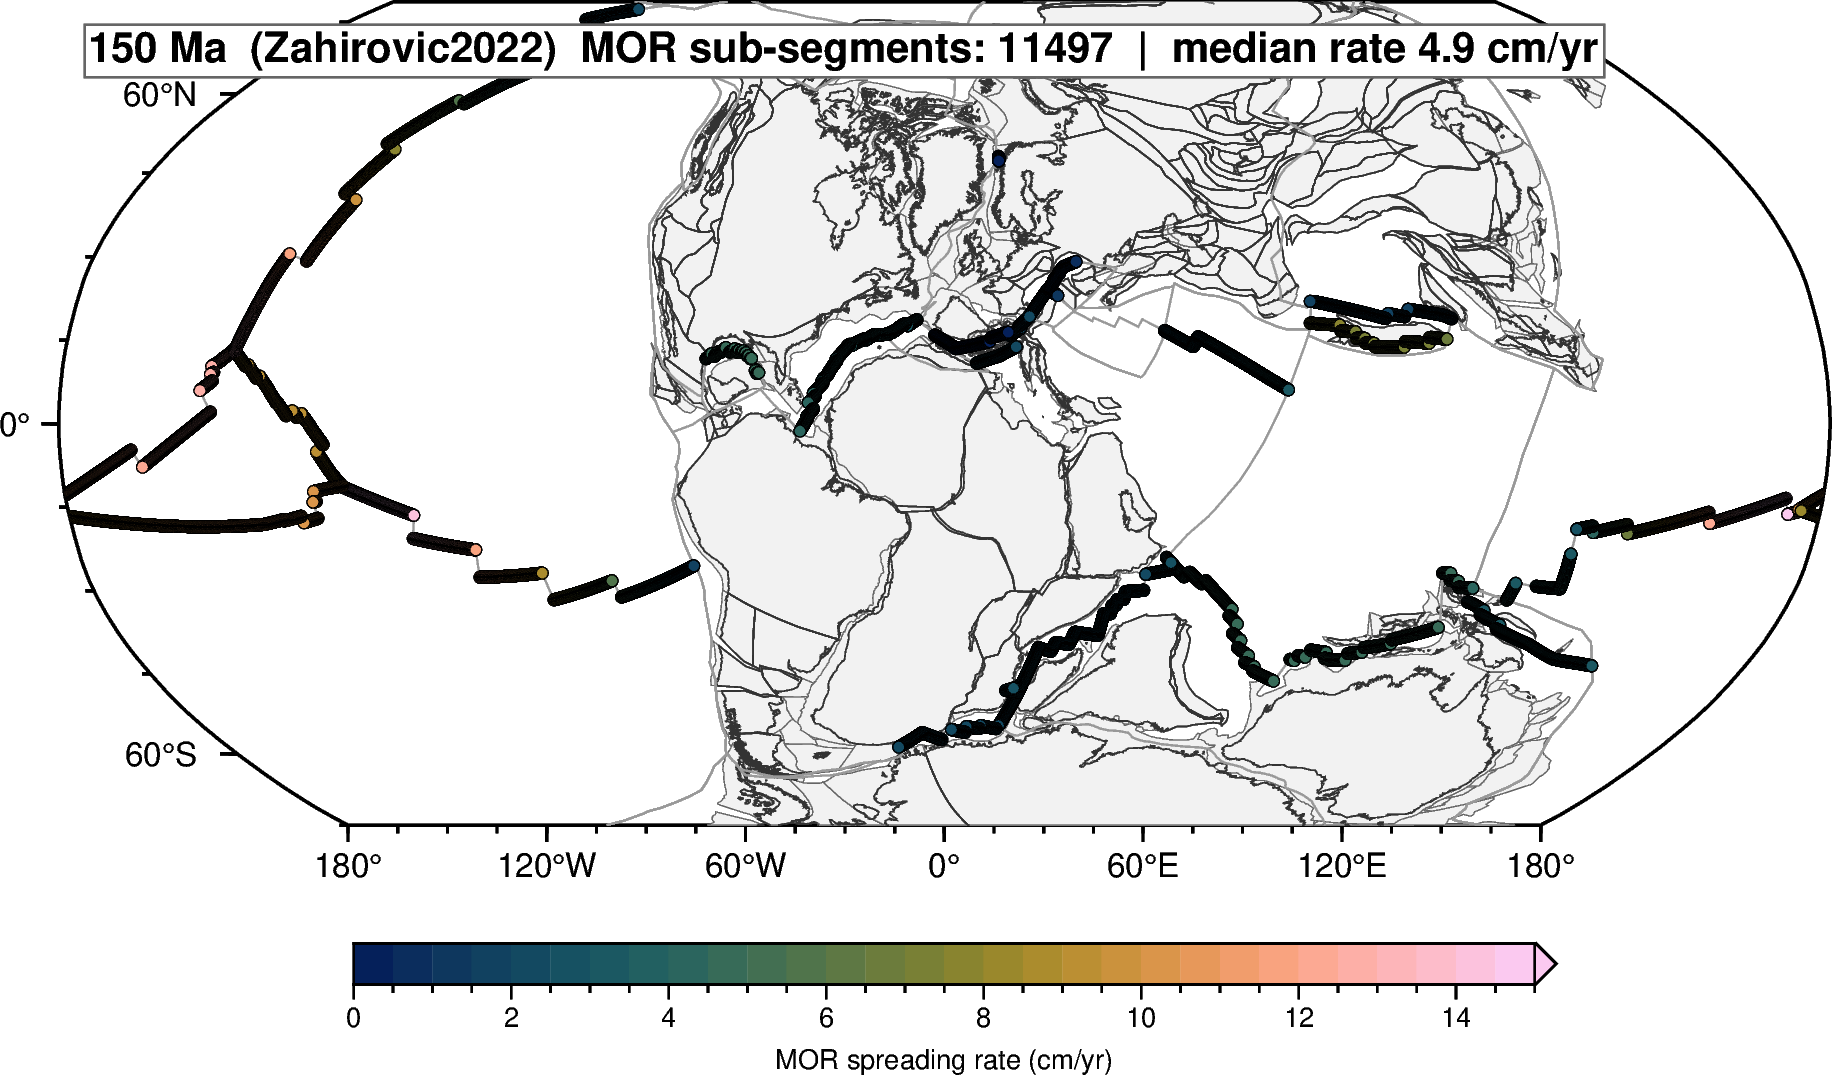

  rendering 175 Ma ...


    (skip velocity arrows: NameError: name 'calculate_plate_motion_arrows' is not defined)


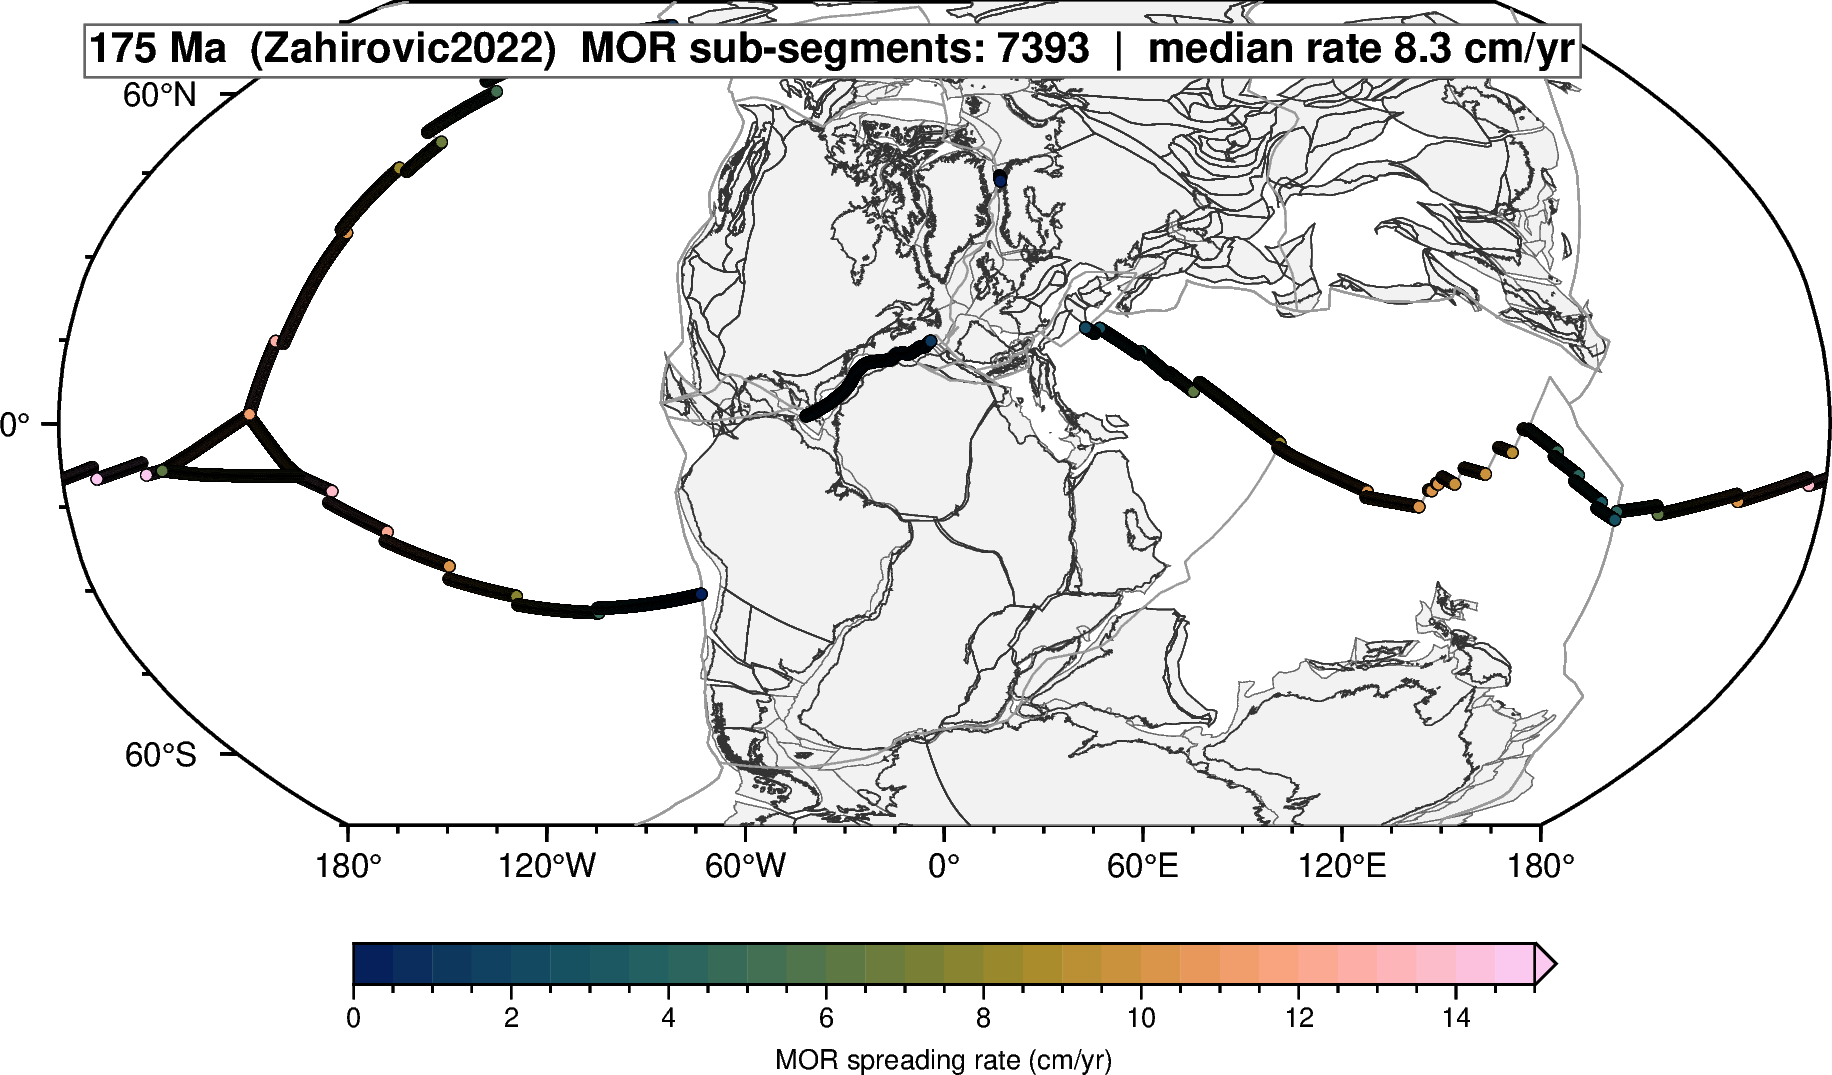

  rendering 200 Ma ...


    (skip velocity arrows: NameError: name 'calculate_plate_motion_arrows' is not defined)


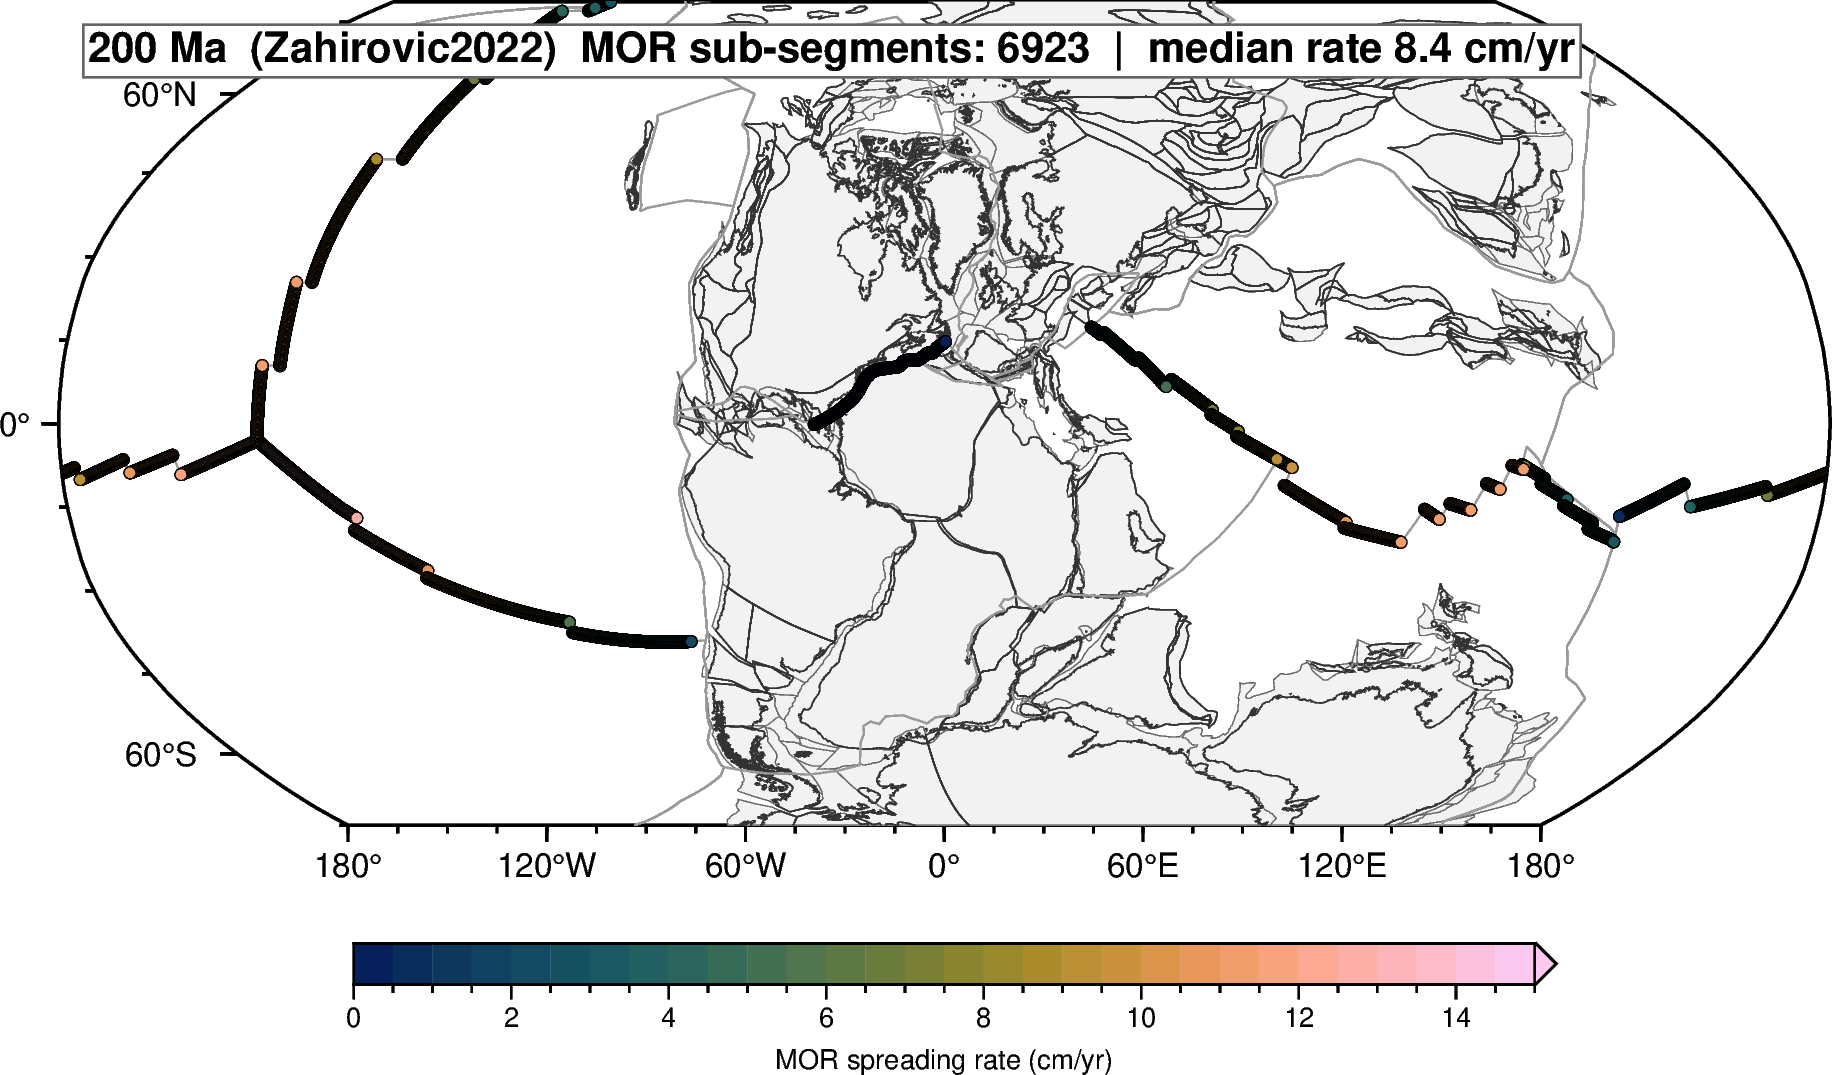

In [5]:
def render_mor_map(time, out_path=None, width_cm=15):
    lon, lat, rate = get_mor_points(time)

    gplot = gplately.PlotTopologies(
        plate_reconstruction=recon,
        coastlines=model_pmm.get_coastlines(),
        continents=model_pmm.get_continental_polygons(),
        COBs=model_pmm.get_COBs(),
        time=float(time),
        plot_engine=gplately.PygmtPlotEngine(),
    )

    fig = pygmt.Figure()
    fig.basemap(region=REGION_GLOBAL, projection=f"N{width_cm}c", frame="af")

    try:
        gplot.plot_continents(fig, fill="gray95", pen="0.2p,gray40")
        gplot.plot_coastlines(fig, pen="0.3p,gray20")
    except Exception:
        pass

    try:
        engine = gplately.PygmtPlotEngine()
        engine.plot_geo_data_frame(fig, gplot.get_all_topological_sections(),
                                    pen="0.4p,gray60")
    except Exception:
        pass

    # --- Plate-motion vector overlay (dark-grey arrows under the anomaly layer)
    try:
        _snap = topological_model.topological_snapshot(float(time))
        _alons, _alats, _ae, _an = calculate_plate_motion_arrows(
            _snap, region=REGION_GLOBAL, spacing_deg=ARROW_SPACING_DEG)
        if len(_alons):
            _speed = np.sqrt(_ae ** 2 + _an ** 2)
            _azimuth = np.rad2deg(np.arctan2(_ae, _an))
            _m = _speed >= ARROW_MIN_SPEED_CM_YR
            if _m.any():
                fig.plot(x=_alons[_m], y=_alats[_m],
                          style="V0.15c+e+a35",
                          direction=[_azimuth[_m], ARROW_VEL_SCALE * _speed[_m]],
                          fill="gray25", pen="0.3p,gray25")
    except Exception as _e:
        print(f"    (skip velocity arrows: {type(_e).__name__}: {_e})")


    if len(lon) > 0:
        pygmt.makecpt(cmap="batlow", series=[CPT_MIN, CPT_MAX, CPT_STEP], background="o")
        fig.plot(x=lon, y=lat, fill=rate, cmap=True,
                  style="c0.10c", pen="0.2p,black")
        fig.colorbar(cmap=True, position="JBC+w10c/0.35c+h+o0c/1c+ef",
                      frame=[f"xa2f0.5+lMOR spreading rate (cm/yr)"])

    med_rate = float(np.median(rate)) if len(rate) else 0.0
    fig.text(text=f"{int(time)} Ma  ({MODEL_NAME})  MOR sub-segments: {len(lon)}  |  "
                   f"median rate {med_rate:.1f} cm/yr",
              position="TL", offset="0.25c/-0.25c", justify="TL",
              font="10p,Helvetica-Bold,black", fill="white", pen="0.5p,gray40")

    if out_path is not None:
        fig.savefig(str(out_path), dpi=100)
        return None
    return fig

for _age in SNAPSHOT_AGES_MA:
    print(f"  rendering {_age} Ma ...")
    _f = render_mor_map(_age, width_cm=15)
    _f.show(width=900)


### How to read these maps

- **Median spreading rate** printed in the title stamp — this is your headline sanity check. Modern Earth's global median is \~5 cm/yr; a snapshot in the 100-200 Ma window should land somewhere similar (potentially slightly higher during the Cretaceous superchron because of the fast Pacific-Farallon system).
- **Colour distribution** — a well-behaved map should look mostly greenish-blue (2-6 cm/yr) with a few bright-yellow super-fast segments in the tropics (East-Pacific-Rise-analogue) and a few dark segments at slow ultra-slow ridges (Arctic-analogue).
- **Saturated (top-CPT) segments** — bright yellow at 15 cm/yr + `+ef` overflow arrow lit means at least one sub-segment exceeds 15 cm/yr. Zoom in on that segment: rates > 20 cm/yr are almost certainly a rotation or plate-ID artefact rather than a real ridge running at 20+ cm/yr.
- **Ridge continuity** — a real ridge system produces a spatially-coherent rate pattern (e.g. slow at the poles, faster at the equator). A single hot pixel on an otherwise slow ridge is an anomaly.


## 4. Compact MP4 video at 1-Myr cadence over 100-200 Ma

Same rendering as §3, one frame per 1-Myr step. Note that PTT tessellation is fast (\~1 second per snapshot) so this video renders significantly quicker than T17's.


In [6]:
FRAMES_DIR.mkdir(exist_ok=True, parents=True)
VIDEO_DIR.mkdir(exist_ok=True, parents=True)

_target_dpi = 100
_frame_width_cm = VIDEO_WIDTH_PX / _target_dpi * 2.54

ages_desc = np.arange(VIDEO_END_MA, VIDEO_START_MA + 1e-6, VIDEO_CADENCE_MA)[::-1]
print(f"  will render {len(ages_desc)} frames at ~{VIDEO_WIDTH_PX} px wide")

frame_paths = []
for i, _age in enumerate(ages_desc):
    _p = FRAMES_DIR / f"frame_{int(round(_age)):04d}Ma.png"
    if not _p.exists():
        render_mor_map(float(_age), out_path=_p, width_cm=_frame_width_cm)
    if i % 10 == 0:
        print(f"    frame {i+1}/{len(ages_desc)}  ({int(round(_age))} Ma)")
    frame_paths.append(_p)
print(f"  ✓ {len(frame_paths)} frames on disk")

import imageio.v2 as imageio
writer = imageio.get_writer(
    str(VIDEO_PATH), fps=VIDEO_FPS, codec="libx264",
    ffmpeg_params=["-crf", str(VIDEO_CRF), "-preset", "veryfast", "-pix_fmt", "yuv420p"],
)
for _p in frame_paths:
    writer.append_data(imageio.imread(str(_p)))
writer.close()
print(f"  ✓ wrote {VIDEO_PATH}  ({VIDEO_PATH.stat().st_size / 1e6:.1f} MB)")

from IPython.display import Video
Video(str(VIDEO_PATH), embed=True, width=VIDEO_WIDTH_PX)


  will render 101 frames at ~800 px wide
    frame 1/101  (200 Ma)
    frame 11/101  (190 Ma)
    frame 21/101  (180 Ma)
    frame 31/101  (170 Ma)
    frame 41/101  (160 Ma)
    frame 51/101  (150 Ma)
    frame 61/101  (140 Ma)
    frame 71/101  (130 Ma)
    frame 81/101  (120 Ma)
    frame 91/101  (110 Ma)


    (skip velocity arrows: NameError: name 'calculate_plate_motion_arrows' is not defined)


    (skip velocity arrows: NameError: name 'calculate_plate_motion_arrows' is not defined)


    (skip velocity arrows: NameError: name 'calculate_plate_motion_arrows' is not defined)


    (skip velocity arrows: NameError: name 'calculate_plate_motion_arrows' is not defined)


    (skip velocity arrows: NameError: name 'calculate_plate_motion_arrows' is not defined)


    frame 101/101  (100 Ma)
  ✓ 101 frames on disk


2026-07-28 21:58:12 - imageio_ffmpeg - WARNING - IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (821, 457) to (832, 464) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Multiple -pix_fmt options specified for stream 0, only the last option '-pix_fmt yuv420p' will be used.


  ✓ wrote Notebooks/videos/T60_debug_mor_velocity.mp4  (1.0 MB)


## Extend this

- **Add trenches for comparison.** Call `recon.tessellate_subduction_zones(time)` in parallel and render trench midpoints in a second colour (e.g. red for convergence rate). Then a single map answers "which segments of the plate margin are fast, and are they doing the right thing?"
- **Tighter CPT range.** For modern-only analyses, set `CPT_MAX = 12` to compress the colour range and make small differences pop. For Mesozoic snapshots, `CPT_MAX = 20` may be more honest.
- **Latitudinal statistics.** Plot median spreading rate per 10° latitude band as a line chart — modern Earth shows a strong latitudinal dependence (faster ridges at low latitudes because of Pacific superplume).
- **Compare against T17.** T17 tags sign anomalies; T18 tags magnitude anomalies. A segment that appears in both maps has a compound problem (wrong sign AND unrealistically high rate) worth prioritising for repair.

## Related resources

- PlateTectonicTools: <https://github.com/EarthByte/PlateTectonicTools> — provides the `tessellate_mid_ocean_ridges` primitive.
- Companion notebooks: **T17** sign-anomaly diagnostics, **T19** topology construction anomalies, **T20** feature extractability at subduction zones.

## References

- Mather, B.R., et al. (2024) Deep time spatio-temporal data analysis using pyGPlates with PlateTectonicTools and GPlately. *Applied Computing and Geosciences* 22, 100152.
- Zahirovic, S., Eleish, A., Doss, S., Pall, J., Cannon, J., Pistone, M., Tetley, M.G., Young, A. & Fox, P. (2022). Subduction and carbonate platform interactions. *Geoscience Data Journal* 9(2), 371-383. https://doi.org/10.1002/gdj3.146
